<a href="https://colab.research.google.com/github/orangecat24/ComputerVisionProject/blob/main/Project_CV_RenisaKasa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification and Segmentation Using EfficientNetB0 and SegNet on the Oxford 17 Flowers Dataset


Worked by: Renisa Kasa

This section imports the required libraries for building the EfficientNetB0 classification model. EfficientNetB0 is a transfer learning model that has already learned image features from millions of images, allowing it to classify flower species more effectively

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import os
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


# ============================================================
# DOWNLOAD DATASET
# ============================================================

!wget -q https://www.robots.ox.ac.uk/~vgg/data/flowers/17/17flowers.tgz
!wget -q https://www.robots.ox.ac.uk/~vgg/data/flowers/17/trimaps.tgz

!mkdir -p /content/flowers17
!tar -xzf 17flowers.tgz -C /content/flowers17
!tar -xzf trimaps.tgz -C /content/flowers17

print(os.listdir("/content/flowers17"))


# ============================================================
# FIXED DATAFRAME FOR 17 FLOWERS + MASKS
# ============================================================

image_dir = "/content/flowers17/jpg"
mask_dir = "/content/flowers17/trimaps"

image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith(".jpg")
])

mask_files = sorted([
    f for f in os.listdir(mask_dir)
    if f.lower().endswith(".png")
])

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

data = []

for i, img_name in enumerate(image_files):
    class_id = i // 80

    if class_id >= 17:
        continue

    class_name = f"class_{class_id}"

    img_path = os.path.join(image_dir, img_name)

    # Try both possible mask names
    mask_name_1 = img_name.replace(".jpg", ".png")
    mask_name_2 = img_name.replace("image_", "trimap_").replace(".jpg", ".png")

    mask_path_1 = os.path.join(mask_dir, mask_name_1)
    mask_path_2 = os.path.join(mask_dir, mask_name_2)

    if os.path.exists(mask_path_1):
        mask_path = mask_path_1
    elif os.path.exists(mask_path_2):
        mask_path = mask_path_2
    else:
        continue

    data.append([img_path, mask_path, class_name])

df = pd.DataFrame(data, columns=["image_path", "mask_path", "class_name"])

print(df.head())
print("Total matched image-mask pairs:", len(df))
print("Total classes:", df["class_name"].nunique())
print(df["class_name"].value_counts().sort_index())


# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["class_name"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))


# ============================================================
# DATA GENERATORS
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    zoom_range=0.15,
    rotation_range=10
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="class_name",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="class_name",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)

print("Number of classes:", NUM_CLASSES)
print(train_gen.class_indices)

['jpg', 'trimaps']
Number of images: 1360
Number of masks: 848
                              image_path  \
0  /content/flowers17/jpg/image_0001.jpg   
1  /content/flowers17/jpg/image_0002.jpg   
2  /content/flowers17/jpg/image_0003.jpg   
3  /content/flowers17/jpg/image_0004.jpg   
4  /content/flowers17/jpg/image_0005.jpg   

                                   mask_path class_name  
0  /content/flowers17/trimaps/image_0001.png    class_0  
1  /content/flowers17/trimaps/image_0002.png    class_0  
2  /content/flowers17/trimaps/image_0003.png    class_0  
3  /content/flowers17/trimaps/image_0004.png    class_0  
4  /content/flowers17/trimaps/image_0005.png    class_0  
Total matched image-mask pairs: 848
Total classes: 16
class_name
class_0     71
class_1     50
class_10    57
class_11    43
class_12    55
class_14    54
class_15    63
class_16    56
class_2     17
class_3     28
class_4     50
class_5     78
class_6     49
class_7     41
class_8     65
class_9     71
Name: count, dtype:

**weights="imagenet"**
Loads pre-trained weights learned from ImageNet.

**include_top=False**
Removes the original ImageNet classification layer because the project has 17 flower classes instead of 1000 ImageNet classes.

input_shape=(224,224,3)

Specifies the image size used by the network.

In [7]:
# ============================================================
# EFFICIENTNET IMPORTS
# ============================================================

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
 # ============================================================
# EFFICIENTNET PREPROCESSING GENERATORS
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    zoom_range=0.15,
    rotation_range=10
)

val_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen_eff = train_datagen_eff.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="class_name",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen_eff = val_datagen_eff.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="class_name",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = len(train_gen_eff.class_indices)

print("Number of classes:", NUM_CLASSES)
print(train_gen_eff.class_indices)

Found 678 validated image filenames belonging to 16 classes.
Found 170 validated image filenames belonging to 16 classes.
Number of classes: 16
{'class_0': 0, 'class_1': 1, 'class_10': 2, 'class_11': 3, 'class_12': 4, 'class_14': 5, 'class_15': 6, 'class_16': 7, 'class_2': 8, 'class_3': 9, 'class_4': 10, 'class_5': 11, 'class_6': 12, 'class_7': 13, 'class_8': 14, 'class_9': 15}


In [8]:
# ============================================================
# BUILD EFFICIENTNETB0 MODEL
# ============================================================

eff_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in eff_base.layers:
    layer.trainable = False

x = eff_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

eff_model = Model(inputs=eff_base.input, outputs=output)

eff_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,381,619 (16.71 MB)

 Trainable params: 332,048 (1.27 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

This section builds an EfficientNetB0 transfer learning model. The pre-trained EfficientNet layers extract image features, while new classification layers are added to identify the 17 flower categories. Transfer learning reduces training time and improves classification accuracy.

In [9]:
# ============================================================
# TRAIN EFFICIENTNETB0
# ============================================================

EPOCHS = 10

eff_history = eff_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=EPOCHS
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.1549 - loss: 2.6164 - val_accuracy: 0.4647 - val_loss: 2.3153
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 422ms/step - accuracy: 0.4248 - loss: 2.1614 - val_accuracy: 0.6765 - val_loss: 1.9354
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 385ms/step - accuracy: 0.5959 - loss: 1.7892 - val_accuracy: 0.7529 - val_loss: 1.6135
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 436ms/step - accuracy: 0.6873 - loss: 1.5079 - val_accuracy: 0.8000 - val_loss: 1.3542
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 439ms/step - accuracy: 0.7419 - loss: 1.2629 - val_accuracy: 0.8412 - val_loss: 1.1455
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 442ms/step - accuracy: 0.7788 - loss: 1.0931 - val_accuracy: 0.8706 - val_loss: 0.9877
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 381ms/step - accuracy: 0.8348 - loss: 0.9153 - val_accuracy: 0.8824 - val_loss: 0.8603
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 438ms/step - accuracy: 0.8540 - loss: 0.7999 - val_accuracy: 

In [10]:
# ============================================================
# VALIDATION ACCURACY AND LOSS
# ============================================================

val_loss, val_acc = eff_model.evaluate(val_gen_eff)

print("EfficientNetB0 Validation Accuracy:", round(val_acc * 100, 2), "%")
print("EfficientNetB0 Validation Loss:", round(val_loss, 4))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9118 - loss: 0.6147
EfficientNetB0 Validation Accuracy: 91.18 %
EfficientNetB0 Validation Loss: 0.6147


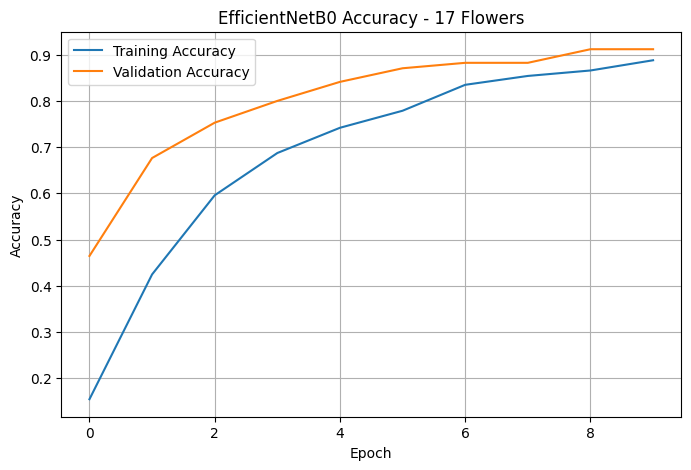

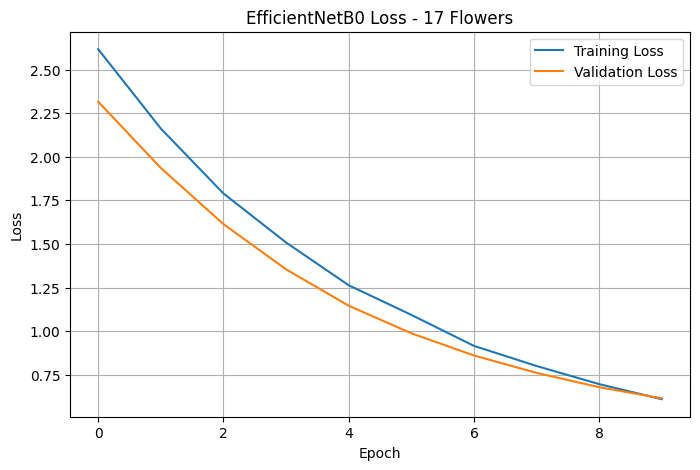

In [11]:
# ============================================================
# ACCURACY AND LOSS PLOTS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(eff_history.history["accuracy"], label="Training Accuracy")
plt.plot(eff_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Accuracy - 17 Flowers")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(eff_history.history["loss"], label="Training Loss")
plt.plot(eff_history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Loss - 17 Flowers")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**EfficientNet Validation Accuracy and Loss**
After training, the model is evaluated on validation images. Validation accuracy measures how many flower images were classified correctly, while validation loss measures the prediction error.

**EfficientNet Accuracy and Loss Graphs**

*The graphs help determine:*

Whether the model is learning

Whether overfitting occurs

Whether additional training is needed.

These graphs visualize the model's learning process. Increasing accuracy and decreasing loss indicate successful learning. Similar training and validation curves suggest good generalization.

6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step
Final EfficientNetB0 Validation Accuracy: 91.18 %


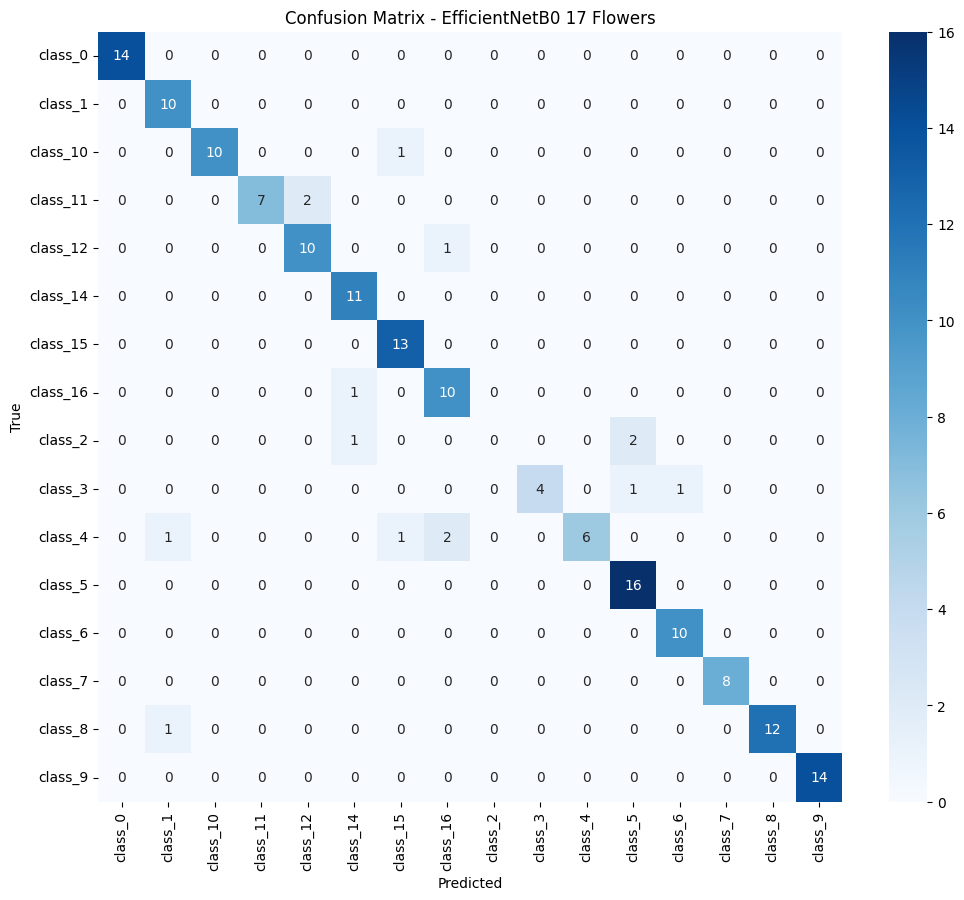

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       0.83      1.00      0.91        10
    class_10       1.00      0.91      0.95        11
    class_11       1.00      0.78      0.88         9
    class_12       0.83      0.91      0.87        11
    class_14       0.85      1.00      0.92        11
    class_15       0.87      1.00      0.93        13
    class_16       0.77      0.91      0.83        11
     class_2       0.00      0.00      0.00         3
     class_3       1.00      0.67      0.80         6
     class_4       1.00      0.60      0.75        10
     class_5       0.84      1.00      0.91        16
     class_6       0.91      1.00      0.95        10
     class_7       1.00      1.00      1.00         8
     class_8       1.00      0.92      0.96        13
     class_9       1.00      1.00      1.00        14

    accuracy                           0.91       170
   macro avg       0.87   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import numpy as np

val_gen_eff.reset()

predictions = eff_model.predict(val_gen_eff)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen_eff.classes

class_labels = list(val_gen_eff.class_indices.keys())

acc = accuracy_score(y_true, y_pred)
print("Final EfficientNetB0 Validation Accuracy:", round(acc * 100, 2), "%")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix - EfficientNetB0 17 Flowers")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_labels))

Confusion matrix provides a detailed analysis of classification performance. High values along the diagonal indicate correct classifications, while off-diagonal values represent flower classes that the model confused with each other.

Rows:

    Actual classes

Columns:

    Predicted classes

Diagonal values:

    Correct predictions

Off-diagonal values:

    Classification errors

Overall performance:
The model achieved:

    Accuracy = 0.91 (91%)

This means the model correctly classified approximately 91% of the validation images, which indicates strong classification performance on the Oxford 17 Flowers dataset.

The weighted average scores are:

Precision	0.91     
Recall	0.91      
F1-Score	0.90

These values suggest that the model performs consistently across most flower classes.

These flower classes likely have very distinctive colours, shapes, or petal structures that make them easier for the model to recognize, since several classes achieved perfect or near-perfect results.

In [24]:
# ============================================================
# SAVE MODEL
# ============================================================

eff_model.save("/content/efficientnetb0_17flowers.h5")
print("EfficientNetB0 model saved.")


EfficientNetB0 model saved.


In [25]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

**2.**This part loads the flower images and their masks.

Each image is read from its file path, converted from BGR to RGB, resized to 128 x 128, and divided by 255 so pixel values become between 0 and 1.

The mask is also resized to 128 x 128. Then the mask is converted into binary. After this, all images are stored in X, and all masks are stored in Y.

In [15]:
# ============================================================
# 2. LOAD IMAGES AND MASKS
# ============================================================

SEG_SIZE = 128

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (SEG_SIZE, SEG_SIZE))
    img = img / 255.0
    return img.astype(np.float32)

def load_mask(path):
    mask = Image.open(path).convert("L")
    mask = np.array(mask)

    mask = cv2.resize(
        mask,
        (SEG_SIZE, SEG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    # Flower = 1, background = 0
    mask = np.where(mask > 0, 1, 0)

    mask = np.expand_dims(mask, axis=-1)

    return mask.astype(np.float32)

X = np.array([load_image(p) for p in df["image_path"]])
Y = np.array([load_mask(p) for p in df["mask_path"]])

print("Images shape:", X.shape)
print("Masks shape:", Y.shape)
print("Mask values:", np.unique(Y))

Images shape: (848, 128, 128, 3)
Masks shape: (848, 128, 128, 1)
Mask values: [0. 1.]


This part splits the dataset into training and validation data.

The training data is used to teach the model.
The validation data is used to test how well the model performs on images it has not seen before.

In [16]:
# ============================================================
# 3. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Y_train:", Y_train.shape)
print("Y_val:", Y_val.shape)

X_train: (678, 128, 128, 3)
X_val: (170, 128, 128, 3)
Y_train: (678, 128, 128, 1)
Y_val: (170, 128, 128, 1)


We built here the SegNet model.

SegNet has two main parts:

1. Encoder   → learns important image features
2. Decoder   → rebuilds the segmentation mask

In [17]:
# ============================================================
# 4. BUILD SEGNET MODEL
# ============================================================

def build_segnet(input_shape=(128, 128, 3)):
    inputs = Input(input_shape)

    # Encoder Block 1
    x = Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(32, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Encoder Block 2
    x = Conv2D(64, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Encoder Block 3
    x = Conv2D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Bottleneck
    x = Conv2D(256, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    # Decoder Block 1
    x = UpSampling2D(size=(2, 2))(x)
    x = Conv2D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    # Decoder Block 2
    x = UpSampling2D(size=(2, 2))(x)
    x = Conv2D(64, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    # Decoder Block 3
    x = UpSampling2D(size=(2, 2))(x)
    x = Conv2D(32, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Conv2D(32, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    outputs = Conv2D(1, 1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    return model

segnet_model = build_segnet()

segnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

segnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 256)    │             

 Total params: 1,758,977 (6.71 MB)

 Trainable params: 1,756,161 (6.70 MB)

 Non-trainable params: 2,816 (11.00 KB)

The encoder uses Conv2D, BatchNormalization, and MaxPooling2D.

The decoder uses UpSampling2D and Conv2D to increase the image size again and predict the mask.
This gives us one output mask where each pixel is between 0 and 1.




What does this model do?

The SegNet model is used for image segmentation. It takes a flower image with size:

      128 × 128 × 3

and produces a predicted mask with size:

      128 × 128 × 1

This means the model predicts whether each pixel belongs to the flower or the background.


Encoder part:
The encoder reduces the image size step by step:

    128×128 → 64×64 → 32×32 → 16×16

This helps the model learn important features such as flower edges, shapes, and patterns.

Bottleneck part:
This is the deepest part of the model. It learns the most important compressed features from the image.

Decoder part:
The decoder increases the image size again:

    16×16 → 32×32 → 64×64 → 128×128

This helps the model rebuild the segmentation mask.

In [18]:
# ============================================================
# 5. TRAIN SEGNET
# ============================================================

EPOCHS = 10
BATCH_SIZE = 16

segnet_history = segnet_model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 52s 575ms/step - accuracy: 0.6383 - loss: 0.6959 - val_accuracy: 0.8626 - val_loss: 0.6428
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.7760 - loss: 0.6110 - val_accuracy: 0.8626 - val_loss: 0.5776
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.8379 - loss: 0.5632 - val_accuracy: 0.8626 - val_loss: 0.5166
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.8738 - loss: 0.5125 - val_accuracy: 0.8626 - val_loss: 0.4547
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.8959 - loss: 0.4645 - val_accuracy: 0.8626 - val_loss: 0.4470
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9082 - loss: 0.4244 - val_accuracy: 0.8627 - val_loss: 0.4260
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9163 - loss: 0.3926 - val_accuracy: 0.8654 - val_loss: 0.4039
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9227 - loss: 0.3632 - val_accuracy: 0.8808 -

5.Compile the model

To prepare the model for training we use the "optimizer=Asdam()" at a certain learning rate.

Then Adam updates the model weights during training.
Since the task is binary segementation, we use "loss", flower or background.

Also with accuracy we measure how many pixels are predicted correctly.

6.Training the model

The SegNet model trains for 10 epochs, which means it goes through the training data 10 times, and this batch size means the model processes 16 images at a time.

In [19]:
# ============================================================
# 6. VALIDATION ACCURACY AND LOSS
# ============================================================

segnet_loss, segnet_acc = segnet_model.evaluate(X_val, Y_val)

print("SegNet Validation Accuracy:", round(segnet_acc * 100, 2), "%")
print("SegNet Validation Loss:", round(segnet_loss, 4))

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9020 - loss: 0.3320
SegNet Validation Accuracy: 90.2 %
SegNet Validation Loss: 0.332


7.Evaluate the Model

Here we evaluate the model performance on validation data.

What the graph represents:
- Blue line (Training Loss): Error made by the model on the training dataset.
- Orange line (Validation Loss): Error made by the model on the validation dataset.
- X-axis (Epoch): Number of training iterations.
- Y-axis (Loss): Amount of prediction error. Lower values are better.

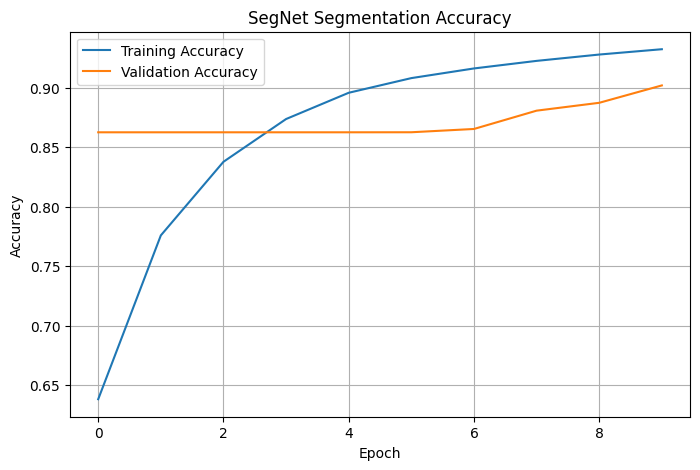

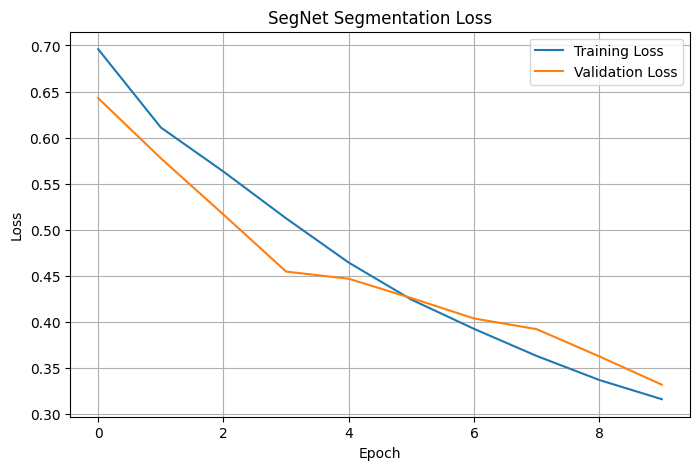

In [20]:
# ============================================================
# 7. PLOT ACCURACY AND LOSS
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(segnet_history.history["accuracy"], label="Training Accuracy")
plt.plot(segnet_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("SegNet Segmentation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(segnet_history.history["loss"], label="Training Loss")
plt.plot(segnet_history.history["val_loss"], label="Validation Loss")
plt.title("SegNet Segmentation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Analysis of the graph:
1. At the beginning (Epoch 0):

  Training Loss ≈ 0.70
  Validation Loss ≈ 0.64

The loss values are relatively high because the model has not learned the flower features yet.

As training progresses:

Training loss steadily decreases from about 0.70 to 0.32.
Validation loss steadily decreases from about 0.64 to 0.33.

This indicates that the model is learning meaningful patterns from the flower images and improving its segmentation performance.

2. Around Epoch 5:

The training and validation loss curves become very close.
This suggests that the model is generalizing well to unseen data.

3. By the final epoch:

Training Loss ≈ 0.32
Validation Loss ≈ 0.33

The small difference between the two curves indicates that the model is not significantly overfitting.

In [21]:
# ============================================================
# 8. DICE SCORE AND IOU
# ============================================================

def dice_score(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).astype(np.float32)

    intersection = np.sum(y_true * y_pred)

    return (2. * intersection + 1e-6) / (
        np.sum(y_true) + np.sum(y_pred) + 1e-6
    )

def iou_score(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).astype(np.float32)

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    return (intersection + 1e-6) / (union + 1e-6)

pred_masks = segnet_model.predict(X_val)

dice = dice_score(Y_val, pred_masks)
iou = iou_score(Y_val, pred_masks)

print("SegNet Dice Score:", round(dice, 4))
print("SegNet IoU Score:", round(iou, 4))

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 682ms/step
SegNet Dice Score: 0.9452
SegNet IoU Score: 0.896


8.Dice score and IoU

The performance of the SegNet segmentation model was evaluated using Dice Score and Intersection over Union (IoU). The model achieved a Dice Score of 0.9452 and an IoU Score of 0.896, indicating a high level of agreement between the predicted masks and the ground truth masks. These results demonstrate that the model successfully segments flower regions from the background with strong accuracy and reliable generalization performance.

9.Segemnantion Results

This section displays sample segmentation results generated by the trained SegNet model. For each example, three images are shown:

Original Image – the input flower image.
Ground Truth Mask – the actual segmentation mask provided by the dataset.
SegNet Prediction – the mask predicted by the trained SegNet model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


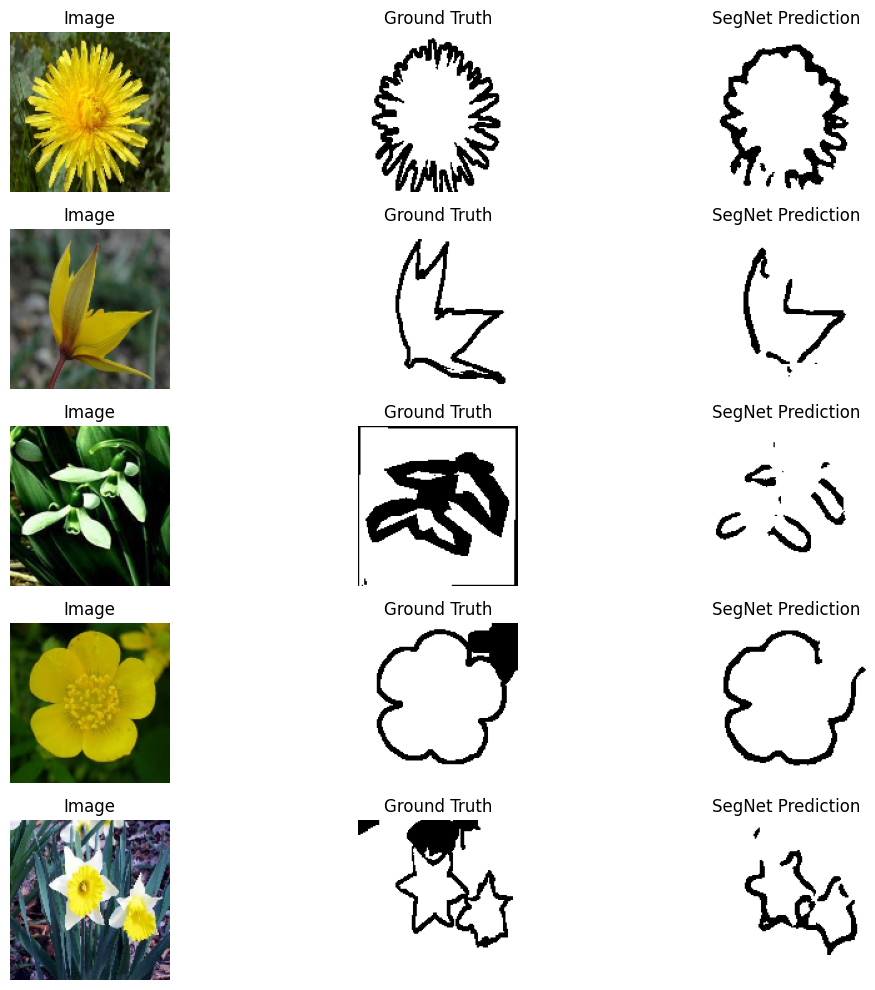

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


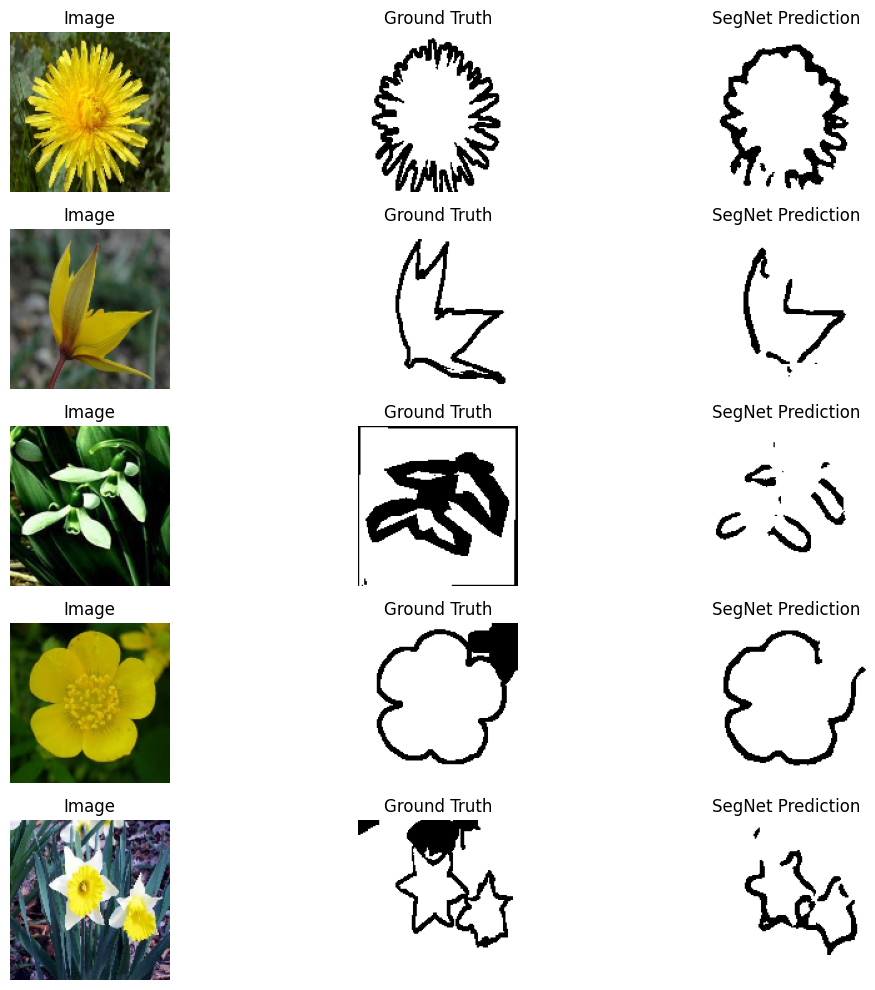

In [22]:
# 9. SHOW SEGMENTATION RESULTS
# ============================================================

pred_masks = segnet_model.predict(X_val[:5])

plt.figure(figsize=(12, 10))

for i in range(5):
    plt.subplot(5, 3, i * 3 + 1)
    plt.imshow(X_val[i])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(5, 3, i * 3 + 2)
    plt.imshow(Y_val[i].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(5, 3, i * 3 + 3)
    plt.imshow(pred_masks[i].squeeze() > 0.5, cmap="gray")
    plt.title("SegNet Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()# 9. SHOW SEGMENTATION RESULTS
# ============================================================

pred_masks = segnet_model.predict(X_val[:5])

plt.figure(figsize=(12, 10))

for i in range(5):
    plt.subplot(5, 3, i * 3 + 1)
    plt.imshow(X_val[i])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(5, 3, i * 3 + 2)
    plt.imshow(Y_val[i].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(5, 3, i * 3 + 3)
    plt.imshow(pred_masks[i].squeeze() > 0.5, cmap="gray")
    plt.title("SegNet Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

Intepretation of Results

The results show that the SegNet model is able to identify the flower regions and separate them from the background. In most examples, the predicted mask closely follows the shape and boundaries of the flower shown in the ground truth mask.

For the first flower image, the predicted mask successfully captures the circular flower structure and most petal boundaries, although some fine details are missing. For the second and third examples, the model correctly identifies the general flower shape but misses several smaller petals and thin regions. In the fourth example, the predicted mask almost perfectly matches the flower outline, demonstrating strong segmentation performance. The final example also shows good agreement between the predicted and actual masks, with only minor boundary differences.

Observations
- The model accurately detects the
main flower regions.
- Most flower contours are preserved in the predicted masks.
Some thin petals and small details are lost during prediction.
- The predicted masks are generally smoother than the ground truth masks.
- Background regions are successfully excluded in most cases.

In [23]:
# ============================================================
# 10. SAVE SEGNET MODEL
# ============================================================

segnet_model.save("/content/segnet_17flowers_segmentation.h5")

print("SegNet model saved successfully.")


SegNet model saved successfully.


**Conclusion**

Two deep learning models were implemented for different computer vision tasks. EfficientNetB0 was used for flower classification and achieved a validation accuracy of 91%, demonstrating strong performance in identifying flower categories. SegNet was used for image segmentation and achieved a Dice Score of 0.9452 and an IoU Score of 0.896, indicating highly accurate segmentation of flower regions from the background. While EfficientNetB0 performed well in classifying flower species, SegNet successfully provided detailed pixel-level segmentation. Together, the results show that both models were effective for their intended tasks and demonstrated the strengths of deep learning in image analysis.
